# Autoencoder model results

Compare normal-only Conv1D and LSTM autoencoders with the same robust MAD threshold rule.

## Run training once (only if needed)

Run the next cell only if output files are missing or you want fresh results. If training has already run, skip it; both autoencoders take time to train.

In [ ]:
# Run only when saved outputs are missing or need regeneration.
!cd .. && python scripts/train.py

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
plt.style.use('seaborn-v0_8-whitegrid')
OUTPUTS = Path('../outputs')
if not (OUTPUTS / 'results.csv').exists():
    raise FileNotFoundError('Run the optional training cell first.')
results = pd.read_csv(OUTPUTS / 'results.csv')
errors = pd.read_csv(OUTPUTS / 'test_errors.csv')
results.round(4)

,model,threshold,validation_median_error,validation_mad,precision,recall,f1,average_precision,roc_auc,tn,fp,fn,tp
0,conv_ae,1.3548,0.4827,0.1961,0.8422,0.9947,0.9121,0.8515,0.9498,2278,349,10,1863
1,lstm_ae,1.0754,0.3954,0.1529,0.8052,0.9973,0.8910,0.8507,0.9503,2175,452,5,1868


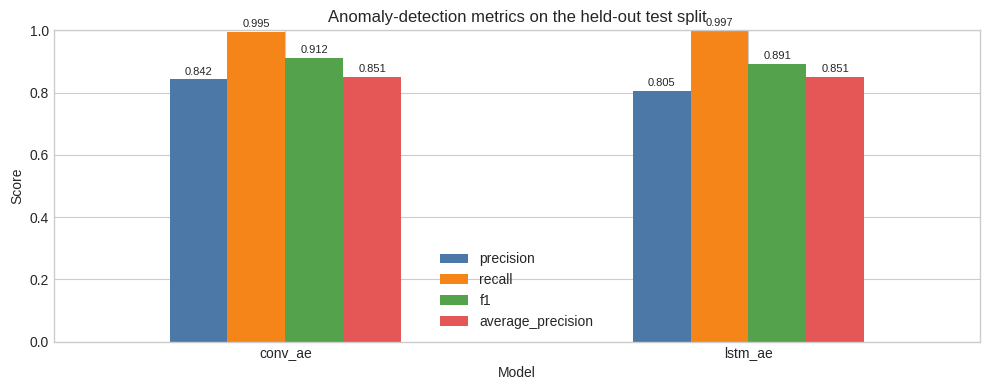

,model,threshold,tn,fp,fn,tp
0,conv_ae,1.3548,2278,349,10,1863
1,lstm_ae,1.0754,2175,452,5,1868


In [2]:
metrics = results.set_index('model')[['precision', 'recall', 'f1', 'average_precision']]
ax = metrics.plot.bar(figsize=(10, 4), ylim=(0, 1), color=['#4C78A8', '#F58518', '#54A24B', '#E45756'])
ax.set(title='Anomaly-detection metrics on the held-out test split', xlabel='Model', ylabel='Score')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=2, fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
results[['model', 'threshold', 'tn', 'fp', 'fn', 'tp']].round(4)

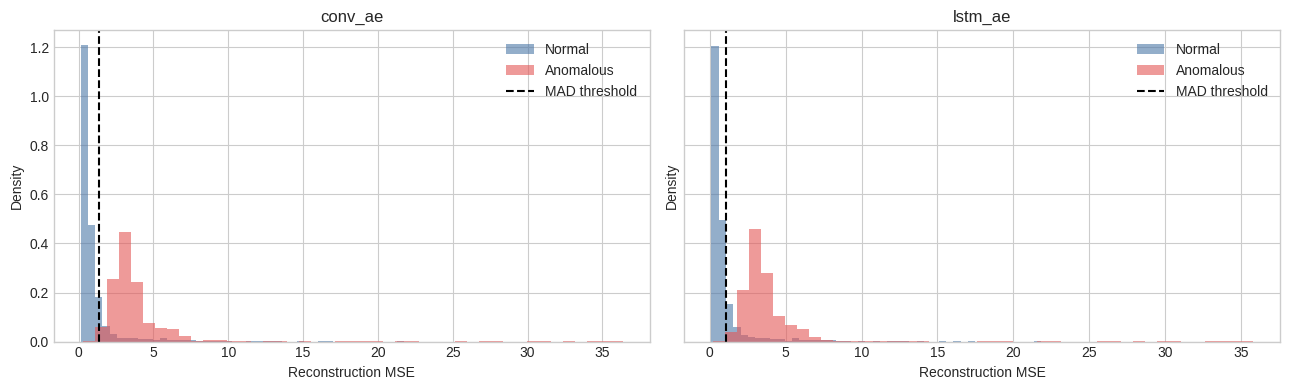

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for axis, model in zip(axes, results['model']):
    subset = errors[errors.model.eq(model)]
    for anomaly, color, label in [(0, '#4C78A8', 'Normal'), (1, '#E45756', 'Anomalous')]:
        axis.hist(subset.loc[subset.is_anomaly.eq(anomaly), 'reconstruction_error'], bins=45, alpha=.6, density=True, color=color, label=label)
    threshold = results.loc[results.model.eq(model), 'threshold'].iloc[0]
    axis.axvline(threshold, color='black', linestyle='--', label='MAD threshold')
    axis.set(title=model, xlabel='Reconstruction MSE', ylabel='Density')
    axis.legend()
plt.tight_layout()
plt.show()